# 01 — Data Understanding

Profile `Results.csv`: shape, quality, exposure, and geography.

In [1]:
import notebook_lib as nb
import pandas as pd

nb.setup_path()
raw = nb.load_results_csv()
deduped, removed = nb.deduplicate_submissions(raw)
cleaned = nb.clean_dataframe(deduped)
print(f"Rows: {len(raw):,} | Columns: {len(raw.columns)} | Dedupe removed: {removed}")
print(f"States: {cleaned['risk_state_cd'].nunique()} | Mean TIV: ${cleaned['clean_total_insured_value_amt'].mean():,.0f}")

Rows: 500 | Columns: 111 | Dedupe removed: 0
States: 30 | Mean TIV: $11,433,684


In [2]:
display(raw.isna().sum().sort_values(ascending=False).head(12))
raw.head(3)

risk_score_water_weather         500
risk_score_liability             500
wildfire_score                   500
named_storm_deductible           500
facultative_ceded_premium_amt    500
risk_score_water_non_weather     500
risk_score_water_backup          500
risk_score_wind_hail             500
risk_score_other                 500
risk_score_lightning             500
risk_score_theft                 500
distance_to_shore                500
dtype: int64

,policy_sk,policy_no,effective_dt,expiration_dt,product_cd,risk_state_cd,insured_nm,insured_type,policy_status,program_type,...,risk_score_wildfire,risk_score_sinkhole_mine,risk_score_all_perils,risk_score_fire,earthquake_score,property_age_years,roof_age_years,exposure_band,has_claim_history,demo_risk_band
0,170309,HO200068107,2025-07-01,2026-07-01,HO,NY,Applegreen LLC,Entity,Active,Non-Admitted,...,NaN,NaN,NaN,NaN,NaN,102,26,Very High TIV,1,CAT / ROL Scored
1,218465,HO200109638,2026-03-20,2027-03-20,HO,NY,Aron Hirsch,Individual,Active,Non-Admitted,...,NaN,NaN,NaN,NaN,NaN,38,9,Very High TIV,1,CAT / ROL Scored
2,169402,HO200043417-01,2025-08-06,2026-08-06,HO,NV,David Copperfield,Individual,Active,Non-Admitted,...,NaN,NaN,NaN,NaN,NaN,17,17,Very High TIV,1,CAT / ROL Scored


Saved: C:\Users\FEDERICO\OneDrive\Escritorio\Vault\DEMOs\metal-peer-risk-scoring\notebooks\reports\figures\01_tiv_distribution.png


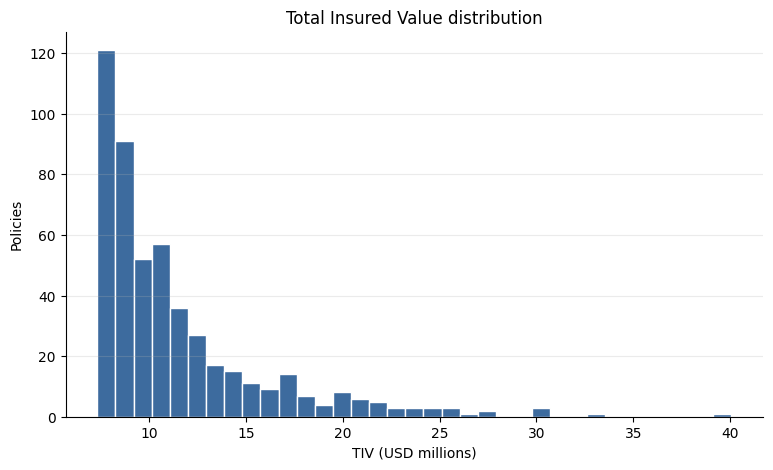

Saved: C:\Users\FEDERICO\OneDrive\Escritorio\Vault\DEMOs\metal-peer-risk-scoring\notebooks\reports\figures\01_state_counts.png


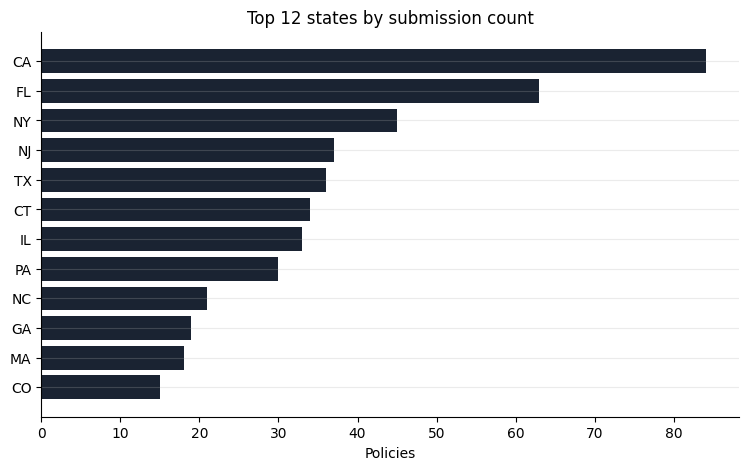

WindowsPath('C:/Users/FEDERICO/OneDrive/Escritorio/Vault/DEMOs/metal-peer-risk-scoring/notebooks/reports/figures/01_state_counts.png')

In [3]:
nb.plot_tiv_distribution(cleaned)
nb.plot_state_counts(cleaned)

Columns map to Metal / EDW submission fields. Derived fields (`exposure_band`, `demo_risk_band`) support triage but are not underwriting labels.